MHLA
корпус - Датасет IMDB — 50 000 отзывов с метками.

задача - определить тональность отзыва на фильм — позитивный (нравится) или негативный (не нравится).

In [1]:
!pip -q install torch torchvision torchaudio --upgrade
!pip -q install datasets scikit-learn matplotlib einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/2

In [2]:
import os, math, time, random, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import rearrange
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [4]:
from datasets import load_dataset
ds = load_dataset('stanfordnlp/imdb')
print(ds)

N_TRAIN = 8000
N_TEST  = 2000

train_raw = ds['train'].shuffle(seed=SEED).select(range(N_TRAIN))
test_raw  = ds['test' ].shuffle(seed=SEED).select(range(N_TEST))
print('Train size:', len(train_raw), 'Test size:', len(test_raw))
print('Пример:', train_raw[0]['text'][:300], '...')
print('Label  :', train_raw[0]['label'])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Train size: 8000 Test size: 2000
Пример: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot  ...
Label  : 1


In [5]:
import re
from collections import Counter

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r"[^a-z0-9']", ' ', text)
    return text.split()

PAD, UNK = '<pad>', '<unk>'
MAX_LEN     = 256
VOCAB_SIZE  = 20000
cnt = Counter()
for row in train_raw:
    cnt.update(tokenize(row['text']))

most_common = cnt.most_common(VOCAB_SIZE - 2)
itos = [PAD, UNK] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}
print('Vocab size:', len(itos))

def encode(text):
    ids = [stoi.get(t, 1) for t in tokenize(text)][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids = ids + [0] * (MAX_LEN - len(ids))
    return ids

Vocab size: 20000


In [6]:
class IMDBDataset(Dataset):
    def __init__(self, hf_split):
        self.x = np.array([encode(r['text']) for r in hf_split], dtype=np.int64)
        self.y = np.array([r['label']       for r in hf_split], dtype=np.int64)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.x[i]), torch.tensor(self.y[i])

train_ds = IMDBDataset(train_raw)
test_ds  = IMDBDataset(test_raw)
VAL_SIZE = 1000
val_idx   = np.arange(len(train_ds))[:VAL_SIZE]
train_idx = np.arange(len(train_ds))[VAL_SIZE:]

from torch.utils.data import Subset
val_ds   = Subset(train_ds, val_idx)
train_ds = Subset(train_ds, train_idx)

print(len(train_ds), len(val_ds), len(test_ds))

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

7000 1000 2000


1. Vanilla Multi-Head Softmax Attention

Сложность O(N^2*d).

In [7]:
class VanillaMHA(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        assert dim % heads == 0
        self.h = heads
        self.d = dim // heads
        self.scale = self.d ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x, mask=None):
        x_ = self.norm(x)
        B, N, C = x_.shape
        q, k, v = self.qkv(x_).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.h)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.h)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.h)

        attn = (q @ k.transpose(-2, -1)) * self.scale  # [B,h,N,N]
        if mask is not None:
            attn = attn.masked_fill(mask[:, None, None, :] == 0, -1e9)
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)
        out  = attn @ v
        out  = rearrange(out, 'b h n d -> b n (h d)')
        return self.proj(out)

2. Plain Linear Attention

Сложность O(N*d^2).

In [8]:
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1, eps=1e-6):
        super().__init__()
        assert dim % heads == 0
        self.h = heads
        self.d = dim // heads
        self.eps = eps
        self.qkv  = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x, mask=None):
        x_ = self.norm(x)
        B, N, C = x_.shape
        q, k, v = self.qkv(x_).chunk(3, dim=-1)
        q = rearrange(q, 'b n (h d) -> b h n d', h=self.h)
        k = rearrange(k, 'b n (h d) -> b h n d', h=self.h)
        v = rearrange(v, 'b n (h d) -> b h n d', h=self.h)

        q = F.relu(q) + self.eps
        k = F.relu(k) + self.eps

        if mask is not None:
            m = mask[:, None, :, None].float()
            k = k * m
            v = v * m

        kv = torch.einsum('bhnd,bhne->bhde', k, v)
        z  = 1.0 / (torch.einsum('bhnd,bhd->bhn', q, k.sum(dim=2)) + self.eps)
        out = torch.einsum('bhnd,bhde->bhne', q, kv) * z.unsqueeze(-1)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.drop(self.proj(out))

3. MHLA

оригинал MHLA для 2D-картинок (окна 4x4 патчей). Для текста просто нарезаю последовательность токенов на P кусков

In [10]:
class BlockDistanceConv1D(nn.Module):
    def __init__(self, num_pieces: int, transform: str = 'exp', exp_sigma: float = 3.0):
        super().__init__()
        self.num_pieces = num_pieces
        idx = torch.arange(num_pieces, dtype=torch.float32)
        D = (idx[:, None] - idx[None, :]).abs()

        if transform == 'linear':
            W = 1.0 - D / D.max()
        elif transform == 'cos':
            W = torch.cos(D / D.max() * math.pi / 4)
        elif transform == 'exp':
            W = torch.exp(-D / exp_sigma)
        elif transform == 'gaussian':
            sigma = D.max() / 3
            W = torch.exp(-(D ** 2) / (2 * sigma ** 2))
        else:
            raise ValueError(transform)

        W = W / (W.sum(dim=0, keepdim=True) + 1e-8)
        self.conv = nn.Conv1d(num_pieces, num_pieces, kernel_size=1, bias=False)
        with torch.no_grad():
            self.conv.weight.copy_(W.unsqueeze(-1))

    def forward(self, x):
        return self.conv(x)


class MHLA_Lite_1D(nn.Module):
    def __init__(self, dim, heads=4, seq_len=256, window_size=16,
                 transform='exp', exp_sigma=3.0, dropout=0.1, eps=1e-6):
        super().__init__()
        assert dim % heads == 0
        assert seq_len % window_size == 0
        self.h = heads
        self.d = dim // heads
        self.W = window_size
        self.P = seq_len // window_size
        self.eps = eps

        self.norm = nn.LayerNorm(dim)
        self.qkv = nn.Linear(dim, dim * 3, bias=False)
        self.q_norm = nn.RMSNorm(self.d)
        self.k_norm = nn.RMSNorm(self.d)

        self.lepe = nn.Conv1d(dim, dim, kernel_size=5, padding=2, groups=dim)

        self.piece_attn = BlockDistanceConv1D(self.P, transform=transform, exp_sigma=exp_sigma)

        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x_ = self.norm(x)
        B, N, C = x_.shape
        q, k, v = self.qkv(x_).chunk(3, dim=-1)

        lepe = self.lepe(v.transpose(1, 2)).transpose(1, 2)

        def to_pieces(t):
            t = rearrange(t, 'b (p w) (h d) -> b h p w d',
                          p=self.P, w=self.W, h=self.h, d=self.d)
            return t
        q = to_pieces(q); k = to_pieces(k); v = to_pieces(v)

        q = F.relu(self.q_norm(q)) + self.eps
        k = F.relu(self.k_norm(k)) + self.eps

        kv = torch.einsum('bhpwd,bhpwe->bhpde', k, v)
        k_sum = k.sum(dim=3)

        BH = B * self.h
        kv_flat = rearrange(kv, 'b h p d e -> (b h) p (d e)')
        kv_mixed = self.piece_attn(kv_flat)
        kv_mixed = rearrange(kv_mixed, '(b h) p (d e) -> b h p d e',
                             b=B, h=self.h, d=self.d, e=self.d)

        ks_flat = rearrange(k_sum, 'b h p d -> (b h) p d')
        ks_mixed = self.piece_attn(ks_flat)
        ks_mixed = rearrange(ks_mixed, '(b h) p d -> b h p d', b=B, h=self.h)

        num = torch.einsum('bhpwd,bhpde->bhpwe', q, kv_mixed)
        denom = torch.einsum('bhpwd,bhpd->bhpw', q, ks_mixed).unsqueeze(-1) + self.eps
        out = num / denom

        out = rearrange(out, 'b h p w d -> b (p w) (h d)')
        out = out + lepe
        return self.drop(self.proj(out))

Классификатор: Embedding -> PositionalEmbedding -> 1 блок attention -> mean-pool -> Linear -> 2 класса

In [11]:
class FFN(nn.Module):
    def __init__(self, dim, mult=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim*mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim*mult, dim),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class TextClassifier(nn.Module):
    def __init__(self, vocab_size, dim=128, heads=4, seq_len=256,
                 num_classes=2, attn_type='softmax',
                 window_size=16, transform='exp'):
        super().__init__()
        self.attn_type = attn_type
        self.seq_len = seq_len

        self.emb     = nn.Embedding(vocab_size, dim, padding_idx=0)
        self.pos_emb = nn.Embedding(seq_len, dim)
        self.emb_drop = nn.Dropout(0.1)

        if attn_type == 'softmax':
            self.attn = VanillaMHA(dim, heads=heads)
        elif attn_type == 'linear':
            self.attn = LinearAttention(dim, heads=heads)
        elif attn_type == 'mhla':
            self.attn = MHLA_Lite_1D(dim, heads=heads, seq_len=seq_len,
                                     window_size=window_size, transform=transform)
        elif attn_type == 'none':
            self.attn = None
        else:
            raise ValueError(attn_type)

        self.ffn = FFN(dim)
        self.head_norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B, N = x.shape
        mask = (x != 0).long()
        pos  = torch.arange(N, device=x.device).unsqueeze(0).expand(B, N)
        h    = self.emb(x) + self.pos_emb(pos)
        h    = self.emb_drop(h)

        if self.attn is not None:
            h = h + self.attn(h, mask=mask) if self.attn_type in ('softmax', 'linear') \
                else h + self.attn(h)
        h = h + self.ffn(h)
        m = mask.unsqueeze(-1).float()
        h = (h * m).sum(1) / m.sum(1).clamp(min=1e-6)
        h = self.head_norm(h)
        return self.head(h)

In [15]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        ps.extend(logits.argmax(-1).cpu().numpy().tolist())
        ys.extend(yb.numpy().tolist())
    return {
        'accuracy' : accuracy_score(ys, ps),
        'f1'       : f1_score(ys, ps),
        'precision': precision_score(ys, ps),
        'recall'   : recall_score(ys, ps),
        'cm'       : confusion_matrix(ys, ps).tolist(),
    }

@torch.no_grad()
def measure_inference_speed(model, loader, n_batches=20):
    model.eval()
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    total = 0
    for i, (xb, _) in enumerate(loader):
        if i >= n_batches: break
        xb = xb.to(DEVICE, non_blocking=True)
        _  = model(xb)
        total += xb.size(0)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    return total / (time.time() - t0)   # samples / sec

def train_model(model, epochs=4, lr=3e-4, weight_decay=1e-2, label=''):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs*len(train_loader))
    crit  = nn.CrossEntropyLoss()

    history = []
    epoch_times = []

    for ep in range(epochs):
        model.train()
        t0 = time.time()
        running = 0.0; n = 0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            running += loss.item() * xb.size(0); n += xb.size(0)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        dt = time.time() - t0
        epoch_times.append(dt)

        val_m = evaluate(model, val_loader)
        history.append({'epoch': ep+1, 'train_loss': running/n,
                        'val_acc': val_m['accuracy'], 'val_f1': val_m['f1'], 'time_s': dt})
        print(f"[{label}] epoch {ep+1:>2}/{epochs}, loss {running/n:.4f}, "
              f"val_acc {val_m['accuracy']:.4f}, val_f1 {val_m['f1']:.4f}, {dt:.1f}s")
    return history, epoch_times

In [24]:
DIM     = 128
HEADS   = 4
EPOCHS  = 200
WINDOW  = 16

results = {}

configs = [
    ('no-attn',  'none',    {}),
    ('softmax',  'softmax', {}),
    ('linear',   'linear',  {}),
    ('mhla',     'mhla',    {'window_size': WINDOW, 'transform': 'exp'}),
]

for name, attn_type, extra in configs:
    print('Training', name)
    torch.manual_seed(SEED)
    model = TextClassifier(
        vocab_size=len(itos),
        dim=DIM, heads=HEADS, seq_len=MAX_LEN,
        attn_type=attn_type, **extra,
    )
    n_params = count_params(model)
    print('Params:', f'{n_params/1e6:.3f}M')

    history, epoch_times = train_model(model, epochs=EPOCHS, label=name)
    test_m = evaluate(model, test_loader)
    ips    = measure_inference_speed(model, test_loader, n_batches=20)
    print(f'TEST: acc={test_m["accuracy"]:.4f}  f1={test_m["f1"]:.4f}  '
          f'p={test_m["precision"]:.4f}  r={test_m["recall"]:.4f}  ips={ips:.1f}')
    results[name] = {
        'params'      : n_params,
        'history'     : history,
        'epoch_times' : epoch_times,
        'avg_epoch_s' : float(np.mean(epoch_times)),
        'test'        : test_m,
        'ips'         : ips,
    }
    del model
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

Training no-attn
Params: 2.725M
[no-attn] epoch  1/200, loss 0.6806, val_acc 0.5760, val_f1 0.6882, 3.7s
[no-attn] epoch  2/200, loss 0.6212, val_acc 0.6910, val_f1 0.7473, 2.0s
[no-attn] epoch  3/200, loss 0.5633, val_acc 0.7680, val_f1 0.7608, 1.5s
[no-attn] epoch  4/200, loss 0.5043, val_acc 0.7720, val_f1 0.7946, 1.1s
[no-attn] epoch  5/200, loss 0.4500, val_acc 0.7910, val_f1 0.7731, 1.1s
[no-attn] epoch  6/200, loss 0.4123, val_acc 0.7760, val_f1 0.8056, 1.1s
[no-attn] epoch  7/200, loss 0.3906, val_acc 0.8110, val_f1 0.8258, 1.1s
[no-attn] epoch  8/200, loss 0.3563, val_acc 0.8240, val_f1 0.8346, 1.4s
[no-attn] epoch  9/200, loss 0.3307, val_acc 0.8230, val_f1 0.8057, 1.3s
[no-attn] epoch 10/200, loss 0.3189, val_acc 0.8290, val_f1 0.8360, 1.1s
[no-attn] epoch 11/200, loss 0.2766, val_acc 0.8310, val_f1 0.8437, 1.1s
[no-attn] epoch 12/200, loss 0.2518, val_acc 0.8270, val_f1 0.8080, 1.1s
[no-attn] epoch 13/200, loss 0.2372, val_acc 0.8390, val_f1 0.8285, 1.1s
[no-attn] epoch 14/

In [25]:
import pandas as pd

rows = []
for name, r in results.items():
    rows.append({
        'model'      : name,
        'params, M'  : round(r['params']/1e6, 3),
        'test acc'   : round(r['test']['accuracy'], 4),
        'test f1'    : round(r['test']['f1'], 4),
        'precision'  : round(r['test']['precision'], 4),
        'recall'     : round(r['test']['recall'], 4),
        'avg epoch s': round(r['avg_epoch_s'], 2),
        'inf samp/s' : round(r['ips'], 1),
    })
df = pd.DataFrame(rows).set_index('model')
df

,"params, M",test acc,test f1,precision,recall,avg epoch s,inf samp/s
model,,,,,,,
no-attn,2.725,0.8280,0.8275,0.8300,0.825,1.19,5443.1
softmax,2.791,0.8230,0.8232,0.8224,0.824,2.68,4958.3
linear,2.791,0.8175,0.8180,0.8159,0.820,1.86,4929.1
mhla,2.792,0.8195,0.8194,0.8198,0.819,2.63,4744.3


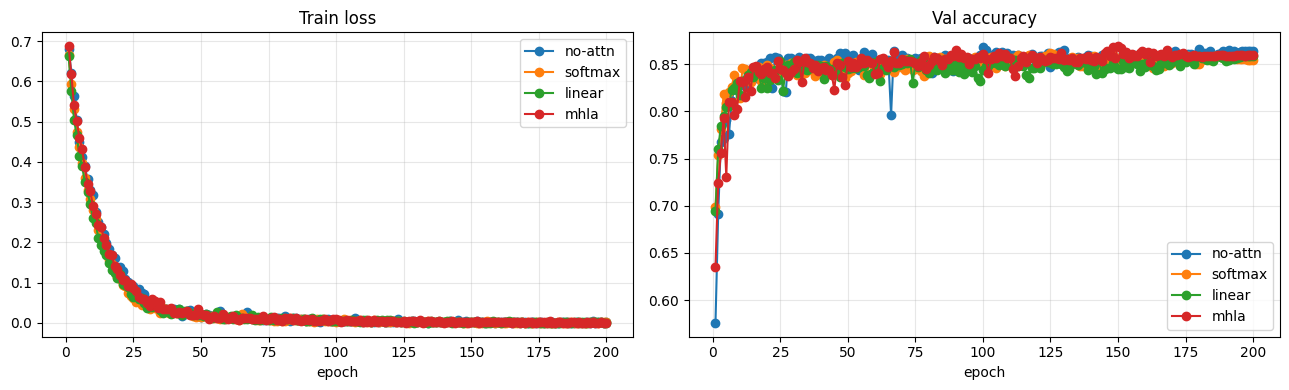

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, r in results.items():
    epochs = [h['epoch'] for h in r['history']]
    axes[0].plot(epochs, [h['train_loss'] for h in r['history']], marker='o', label=name)
    axes[1].plot(epochs, [h['val_acc']    for h in r['history']], marker='o', label=name)
axes[0].set_title('Train loss');     axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].set_title('Val accuracy');   axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

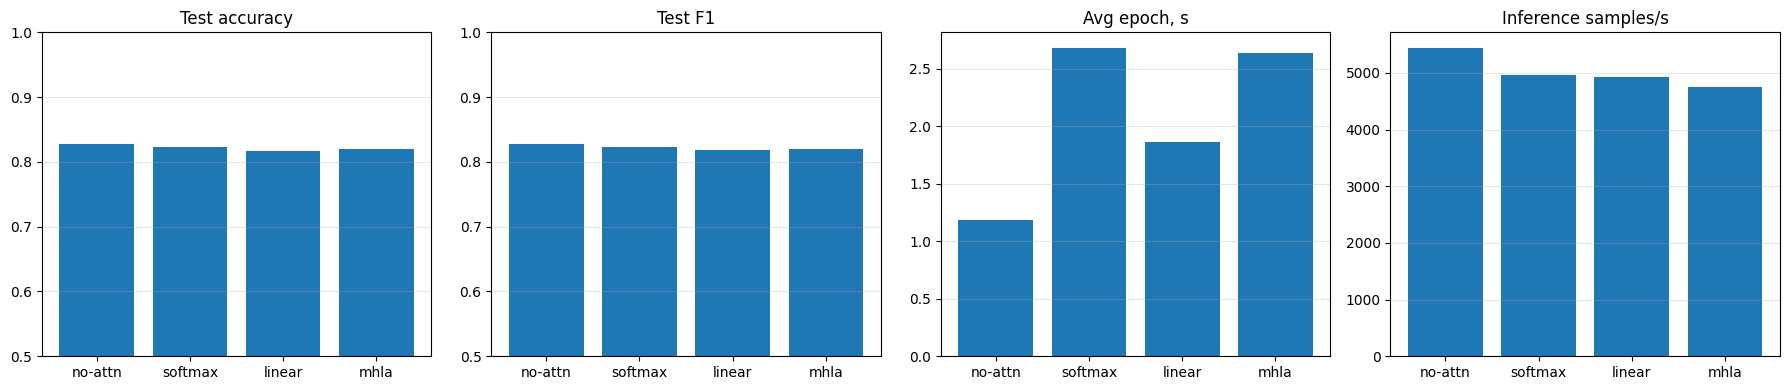

In [27]:
names = list(results.keys())
acc   = [results[n]['test']['accuracy'] for n in names]
f1    = [results[n]['test']['f1']       for n in names]
t_ep  = [results[n]['avg_epoch_s']      for n in names]
ips   = [results[n]['ips']              for n in names]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].bar(names, acc);  axes[0].set_title('Test accuracy'); axes[0].set_ylim(0.5, 1.0)
axes[1].bar(names, f1);   axes[1].set_title('Test F1');       axes[1].set_ylim(0.5, 1.0)
axes[2].bar(names, t_ep); axes[2].set_title('Avg epoch, s')
axes[3].bar(names, ips);  axes[3].set_title('Inference samples/s')
for ax in axes: ax.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

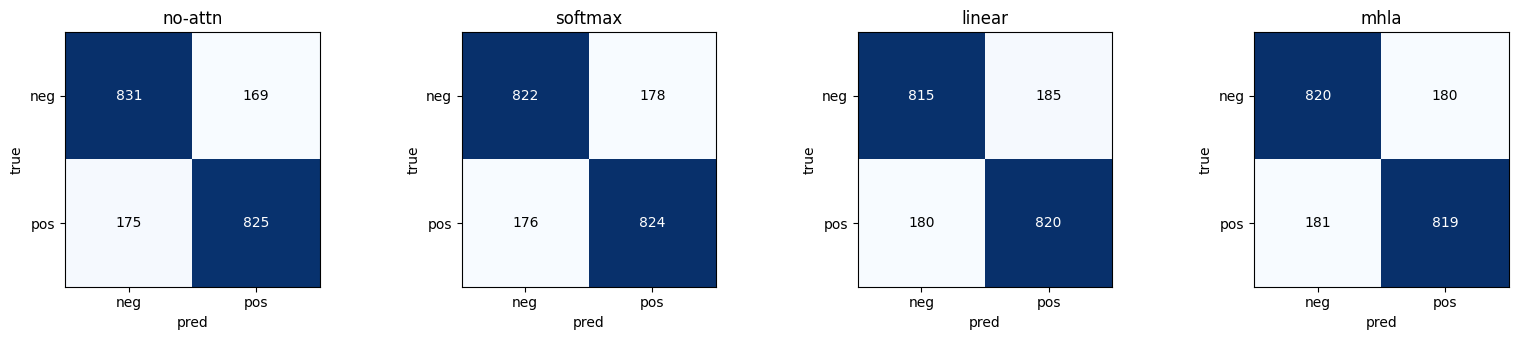

In [28]:
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 3.5))
if len(results) == 1: axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = np.array(r['test']['cm'])
    ax.imshow(cm, cmap='Blues')

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(name); ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['neg','pos']); ax.set_yticklabels(['neg','pos'])
    ax.set_xlabel('pred'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()

Чтобы увидеть преимущество linear/MHLA, сделаю график со временем  forward-pass на батче при разной длине последовательности на тех же модулях

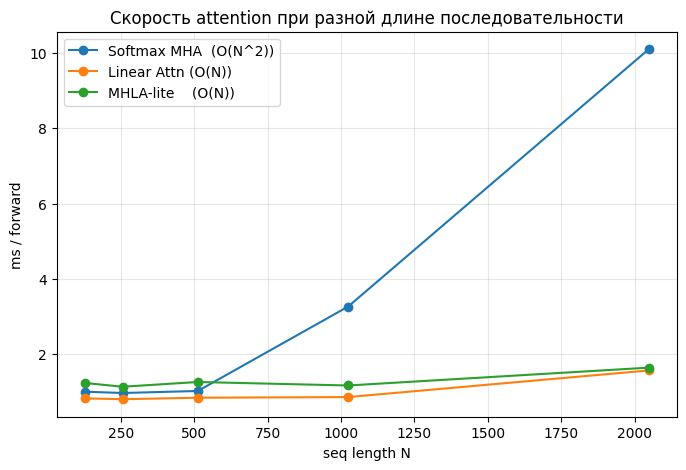

Softmax: ['1.00', '0.97', '1.02', '3.26', '10.10'] ms
Linear : ['0.82', '0.80', '0.84', '0.86', '1.57'] ms
MHLA   : ['1.23', '1.13', '1.26', '1.17', '1.64'] ms


In [30]:
def bench_attn(module, seq_lens, dim=128, batch=4, repeat=10):
    module = module.to(DEVICE).eval()
    out = []
    for N in seq_lens:
        x = torch.randn(batch, N, dim, device=DEVICE)
        for _ in range(3):
            with torch.no_grad(): _ = module(x)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(repeat):
            with torch.no_grad(): _ = module(x)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        out.append((time.time() - t0) * 1000 / repeat)
    return out

seq_lens = [128, 256, 512, 1024, 2048]

softmax_mod = VanillaMHA(128, heads=4)
linear_mod  = LinearAttention(128, heads=4)

t_softmax = bench_attn(softmax_mod, seq_lens)
t_linear  = bench_attn(linear_mod,  seq_lens)
t_mhla = []
for N in seq_lens:
    W = 16 if N % 16 == 0 else 8
    mod = MHLA_Lite_1D(128, heads=4, seq_len=N, window_size=W, transform='exp')
    t_mhla.append(bench_attn(mod, [N])[0])

plt.figure(figsize=(8,5))
plt.plot(seq_lens, t_softmax, marker='o', label='Softmax MHA  (O(N^2))')
plt.plot(seq_lens, t_linear,  marker='o', label='Linear Attn (O(N))')
plt.plot(seq_lens, t_mhla,    marker='o', label='MHLA-lite    (O(N))')
plt.xlabel('seq length N'); plt.ylabel('ms / forward')
plt.title('Скорость attention при разной длине последовательности')
plt.grid(alpha=.3); plt.legend(); plt.show()

print('Softmax:', [f'{v:.2f}' for v in t_softmax], 'ms')
print('Linear :', [f'{v:.2f}' for v in t_linear],  'ms')
print('MHLA   :', [f'{v:.2f}' for v in t_mhla],    'ms')

**Качество**. На IMDB лучшей оказалась модель без attention (acc 0.828), а softmax, linear и MHLA дали практически одинаковый результат (0.818–0.823). Можно сделать два вывода: первый - задача классификации коротких отзывов решается по отдельным словам-маркерам, и глобальные зависимости здесь почти не нужны; второй - MHLA действительно догоняет softmax по качеству (линейное внимание не просело относительно квадратичного)

**Скорость**. Бенчмарк на разных длинах показал ожидаемые результаты: softmax растёт квадратично (1.02 -> 3.26 -> 10.10 мс при N=128…2048), а linear и MHLA остаются почти плоскими (0.82 -> 1.57 и 1.23 -> 1.64 мс). На коротких N=256 (наша задача) softmax даже быстрее, но уже на N=1024 он отстаёт в 3 раза, а на N=2048 — в 6 раз

**Итог**. MHLA получился компромиссом: качество как у softmax, сложность как у linear. Но на коротких текстах (≤256 токенов) его преимущества не раскрываются — overhead на дополнительные операции съедает выигрыш, и проще взять обычный attention или вообще baseline. Реальная польза MHLA проявляется на длинных последовательностях (документы, видео, hi-res картинки), где O(N^2) у softmax становится узким местом